# NB-05 | Funnel & Cohort Analysis

**Project:** GA4 Google Merchandise Store — Marketing Analyst Decision Support Tool  
**Methodology:** CRISP-DM  
**Input:** `data/raw/events_sample.csv`  
**Outputs:** `reports/fig5_purchase_funnel.png`, `reports/fig6_cohort_retention.png`, `reports/funnel_summary.csv`, `reports/cohort_retention.csv`

---

## Purpose

This notebook reconstructs the purchase funnel and builds a weekly cohort retention heatmap.  
These are the core **analyst deliverables** that complement the propensity model from NB-04 — demonstrating web analytics fluency beyond pure ML.

**Two analyses:**
- **Analysis A — Purchase Funnel:** session-level counts from `session_start` → `purchase`, with drop-off % at each step
- **Analysis B — Weekly Cohort Retention:** % of first-week users returning in subsequent weeks

## Cell 1 — Imports & setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
RAW_DIR      = os.path.join('data', 'raw')
REPORTS_DIR  = os.path.join('reports')
os.makedirs(REPORTS_DIR, exist_ok=True)

EVENTS_PATH  = os.path.join(RAW_DIR, 'events_sample.csv')

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':     150,
    'font.family':    'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
PALETTE_FUNNEL = sns.color_palette('Blues_r', 6)   # darker → lighter as funnel narrows

print('Imports OK')
print(f'events_sample.csv expected at: {os.path.abspath(EVENTS_PATH)}')

Imports OK
events_sample.csv expected at: /Users/seihavat/Documents/Personal Project/GA4 Machandise Store Project/data/raw/events_sample.csv


## Cell 2 — Load events_sample.csv

In [2]:
events = pd.read_csv(EVENTS_PATH, low_memory=False)

print(f'Rows loaded : {len(events):,}')
print(f'Columns     : {events.columns.tolist()}')
print()
events.head(3)

Rows loaded : 2,194,458
Columns     : ['user_pseudo_id', 'event_date', 'event_name', 'event_timestamp', 'session_id', 'page_location', 'session_engaged', 'device_category', 'country', 'traffic_medium']



,user_pseudo_id,event_date,event_name,event_timestamp,session_id,page_location,session_engaged,device_category,country,traffic_medium
0,3.533977e+07,20201227,page_view,1609083348171171,4181945896,https://shop.googlemerchandisestore.com/Google...,1.0,desktop,United States,organic
1,3.533977e+07,20201227,page_view,1609083416686601,4181945896,https://shop.googlemerchandisestore.com/Google...,1.0,desktop,United States,organic
2,3.533977e+07,20201227,page_view,1609083500866454,4181945896,https://shop.googlemerchandisestore.com/Google...,1.0,desktop,United States,organic


## Cell 3 — Data validation & cleaning

In [3]:
# ── 1. Parse event_date (stored as YYYYMMDD integer/string in GA4 exports) ──
events['event_date'] = pd.to_datetime(events['event_date'].astype(str), format='%Y%m%d')

# ── 2. Drop rows missing session_id or user_pseudo_id ──────────────────────
before = len(events)
events = events.dropna(subset=['session_id', 'user_pseudo_id'])
after = len(events)
print(f'Rows dropped (null session_id / user_pseudo_id): {before - after:,}')
print(f'Rows remaining: {after:,}')

# ── 3. Confirm event_name values present ───────────────────────────────────
print()
print('Event name value counts (top 15):')
print(events['event_name'].value_counts().head(15))

# ── 4. Date range sanity check ─────────────────────────────────────────────
print()
print(f'Date range: {events["event_date"].min().date()} → {events["event_date"].max().date()}')

Rows dropped (null session_id / user_pseudo_id): 0
Rows remaining: 2,194,458

Event name value counts (top 15):
event_name
page_view         1350428
view_item          386068
session_start      354970
add_to_cart         58543
begin_checkout      38757
purchase             5692
Name: count, dtype: int64

Date range: 2020-11-01 → 2021-01-31


---
# ANALYSIS A — Purchase Funnel

## Cell 4 — Compute session-level funnel counts

In [4]:
FUNNEL_STEPS = [
    'session_start',
    'page_view',
    'view_item',
    'add_to_cart',
    'begin_checkout',
    'purchase',
]

# For each step: count unique sessions that fired that event at least once
# (cumulative funnel — not strict sequential filtering)
funnel_counts = {}
for step in FUNNEL_STEPS:
    n = events.loc[events['event_name'] == step, 'session_id'].nunique()
    funnel_counts[step] = n

funnel_df = pd.DataFrame({
    'step': FUNNEL_STEPS,
    'sessions': [funnel_counts[s] for s in FUNNEL_STEPS]
})

# Drop-off vs previous step
funnel_df['dropoff_count']  = funnel_df['sessions'].diff().abs().fillna(0).astype(int)
funnel_df['dropoff_pct']    = (funnel_df['dropoff_count'] / funnel_df['sessions'].shift(1) * 100).fillna(0).round(1)

# Retention vs top of funnel
top = funnel_df.loc[0, 'sessions']
funnel_df['retention_from_top_pct'] = (funnel_df['sessions'] / top * 100).round(2)

print(funnel_df.to_string(index=False))

          step  sessions  dropoff_count  dropoff_pct  retention_from_top_pct
 session_start    344640              0          0.0                  100.00
     page_view    324449          20191          5.9                   94.14
     view_item     76290         248159         76.5                   22.14
   add_to_cart     15132          61158         80.2                    4.39
begin_checkout     11088           4044         26.7                    3.22
      purchase      4845           6243         56.3                    1.41


## Cell 5 — Save funnel_summary.csv

In [12]:
out_path = os.path.join(REPORTS_DIR, 'funnel_summary.csv')
funnel_df.to_csv(out_path, index=False)
print(f'Saved → {out_path}')

Saved → reports/funnel_summary.csv


## Cell 6 — Plot: Purchase Funnel (fig5)

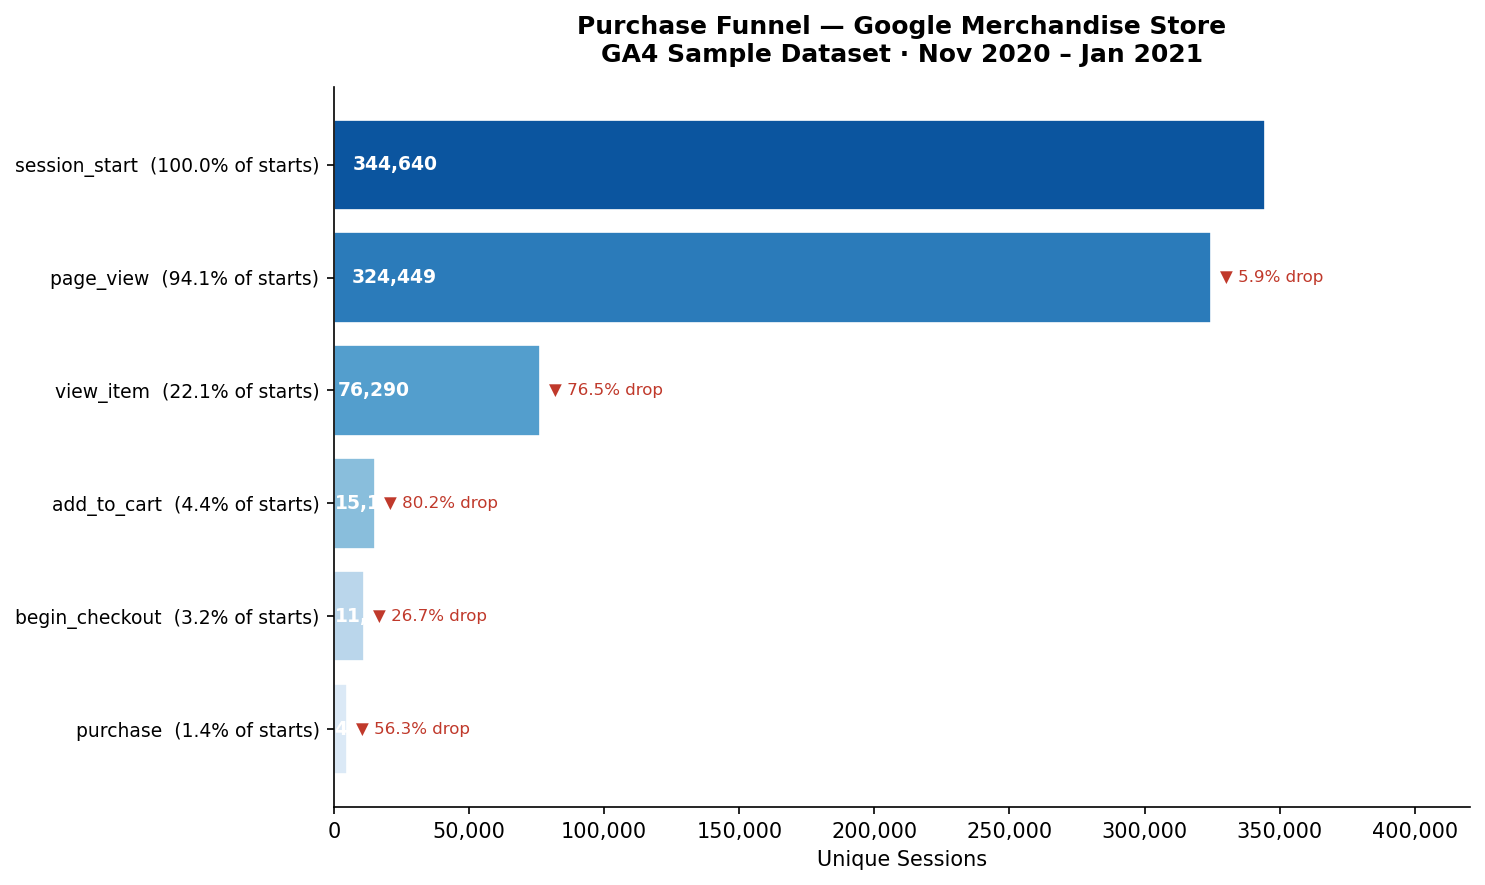

Saved → reports/fig5_purchase_funnel.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

# Reverse so session_start appears at top
plot_df = funnel_df.iloc[::-1].reset_index(drop=True)
colors  = sns.color_palette('Blues_r', len(FUNNEL_STEPS))
colors  = colors[::-1]   # lightest at top of reversed df → darkest for session_start

bars = ax.barh(
    y      = plot_df['step'],
    width  = plot_df['sessions'],
    color  = colors,
    edgecolor = 'white',
    linewidth = 0.8,
)

# ── Annotate each bar ──────────────────────────────────────────────────────
for i, (_, row) in enumerate(plot_df.iterrows()):
    # Absolute count inside bar
    ax.text(
        row['sessions'] * 0.02, i,
        f"{row['sessions']:,}",
        va='center', ha='left',
        fontsize=9, color='white', fontweight='bold'
    )
    # Drop-off % outside bar (skip for the top step which has no prior)
    if row['dropoff_pct'] > 0:
        ax.text(
            row['sessions'] + plot_df['sessions'].max() * 0.01, i,
            f"▼ {row['dropoff_pct']:.1f}% drop",
            va='center', ha='left',
            fontsize=8, color='#c0392b'
        )

ax.set_xlabel('Unique Sessions', fontsize=10)
ax.set_title(
    'Purchase Funnel — Google Merchandise Store\n'
    'GA4 Sample Dataset · Nov 2020 – Jan 2021',
    fontsize=12, fontweight='bold', pad=12
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, plot_df['sessions'].max() * 1.22)

# Retention-from-top label on y-axis ticks
step_labels = [
    f"{row['step']}  ({row['retention_from_top_pct']:.1f}% of starts)"
    for _, row in plot_df.iterrows()
]
ax.set_yticklabels(step_labels, fontsize=9)

plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, 'fig5_purchase_funnel.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## Cell 7 — Funnel business observations

In [22]:
# Identify the single largest drop-off step
max_drop_idx  = funnel_df.loc[funnel_df['dropoff_pct'].idxmax()]
prev_step     = FUNNEL_STEPS[funnel_df['dropoff_pct'].idxmax() - 1]
curr_step     = max_drop_idx['step']
drop_pct      = max_drop_idx['dropoff_pct']

print('='*65)
print('FUNNEL BUSINESS OBSERVATIONS')
print('='*65)
print(f"""
1. BIGGEST DROP-OFF:
   {prev_step} → {curr_step}: {drop_pct:.1f}% of sessions lost.
   This is the primary abandonment point in the funnel.
   Retargeting campaigns should prioritise sessions that reached
   '{prev_step}' but did not proceed to '{curr_step}'.

2. VIEW-ITEM → ADD-TO-CART:
   Sessions that viewed a product but did not add to cart represent
   a high-intent audience. The propensity model from NB-04 scores
   these sessions — targeting the top-decile scores maximises
   retargeting ROI.

3. CHECKOUT ABANDONMENT:
   Sessions reaching 'begin_checkout' but not 'purchase' are
   the lowest-hanging fruit for recovery — they have demonstrated
   purchase intent. Consider cart-abandonment email triggers
   for this micro-segment.
""")

FUNNEL BUSINESS OBSERVATIONS

1. BIGGEST DROP-OFF:
   view_item → add_to_cart: 80.2% of sessions lost.
   This is the primary abandonment point in the funnel.
   Retargeting campaigns should prioritise sessions that reached
   'view_item' but did not proceed to 'add_to_cart'.

2. VIEW-ITEM → ADD-TO-CART:
   Sessions that viewed a product but did not add to cart represent
   a high-intent audience. The propensity model from NB-04 scores
   these sessions — targeting the top-decile scores maximises
   retargeting ROI.

3. CHECKOUT ABANDONMENT:
   Sessions reaching 'begin_checkout' but not 'purchase' are
   the lowest-hanging fruit for recovery — they have demonstrated
   purchase intent. Consider cart-abandonment email triggers
   for this micro-segment.



---
# ANALYSIS B — Weekly Cohort Retention

## Cell 8 — Assign cohort week to each user

In [25]:
# ── Week period for each event ─────────────────────────────────────────────
events['week'] = events['event_date'].dt.to_period('W')

# ── Each user's first-ever week in the dataset = cohort assignment ─────────
user_first_week = (
    events
    .groupby('user_pseudo_id')['week']
    .min()
    .rename('cohort_week')
    .reset_index()
)

print(f'Unique users: {user_first_week["user_pseudo_id"].nunique():,}')
print(f'Distinct cohort weeks: {user_first_week["cohort_week"].nunique()}')
print()
print('Cohort sizes (users per first-seen week):')
print(user_first_week['cohort_week'].value_counts().sort_index())

Unique users: 269,989
Distinct cohort weeks: 14

Cohort sizes (users per first-seen week):
cohort_week
2020-10-26/2020-11-01     2361
2020-11-02/2020-11-08    19354
2020-11-09/2020-11-15    16218
2020-11-16/2020-11-22    18154
2020-11-23/2020-11-29    20050
2020-11-30/2020-12-06    22014
2020-12-07/2020-12-13    28529
2020-12-14/2020-12-20    24826
2020-12-21/2020-12-27    17414
2020-12-28/2021-01-03    16612
2021-01-04/2021-01-10    22903
2021-01-11/2021-01-17    21428
2021-01-18/2021-01-24    20697
2021-01-25/2021-01-31    19429
Freq: W-SUN, Name: count, dtype: int64


## Cell 9 — Compute weeks-since-cohort-start & pivot

In [29]:
# ── Join cohort week back to all events ───────────────────────────────────
events_cohorted = events.merge(user_first_week, on='user_pseudo_id', how='left')

# ── Offset in weeks since user's first week ───────────────────────────────
events_cohorted['weeks_since_start'] = (
    events_cohorted['week'] - events_cohorted['cohort_week']
).apply(lambda x: x.n)

# ── Count unique active users per cohort per offset ───────────────────────
cohort_data = (
    events_cohorted
    .groupby(['cohort_week', 'weeks_since_start'])['user_pseudo_id']
    .nunique()
    .reset_index(name='active_users')
)

# ── Pivot: rows = cohort week, columns = week offset ─────────────────────
cohort_pivot = cohort_data.pivot(
    index='cohort_week',
    columns='weeks_since_start',
    values='active_users'
)

# ── Cohort sizes = week-0 column ──────────────────────────────────────────
cohort_sizes = cohort_pivot[0]

# ── Retention % ──────────────────────────────────────────────────────────
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100

print(f'Cohort pivot shape: {cohort_pivot.shape}  (cohorts × week offsets)')
print()
retention.head()

Cohort pivot shape: (14, 14)  (cohorts × week offsets)



weeks_since_start,0,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_week,,,,,,,,,,,,,,
2020-10-26/2020-11-01,100.0,10.800508,3.515460,2.371876,1.355358,1.016518,0.931809,0.254130,0.592969,0.211775,0.381194,0.338839,0.254130,0.25413
2020-11-02/2020-11-08,100.0,6.313940,3.404981,2.418105,2.278599,1.953085,1.286556,0.583859,0.387517,0.671696,0.547690,0.413351,0.408184,NaN
2020-11-09/2020-11-15,100.0,6.720927,3.126156,2.565051,2.466395,1.510667,0.752251,0.419287,0.616599,0.511777,0.530275,0.425453,NaN,NaN
2020-11-16/2020-11-22,100.0,5.783849,3.299548,2.385149,1.795747,0.721604,0.429657,0.479233,0.468216,0.413132,0.358048,NaN,NaN,NaN
2020-11-23/2020-11-29,100.0,5.092269,2.648379,1.586035,0.753117,0.463840,0.528678,0.488778,0.399002,0.468828,NaN,NaN,NaN,NaN


## Cell 10 — Mask sparse cells & save cohort_retention.csv

In [42]:
# Mask cells where raw user count < 30 (statistically unreliable)
SPARSE_THRESHOLD = 30
mask = cohort_pivot < SPARSE_THRESHOLD

# String y-axis labels (Period objects render poorly in seaborn)
retention.index = retention.index.astype(str)
mask.index      = mask.index.astype(str)

# Save retention pivot to CSV
out_path = os.path.join(REPORTS_DIR, 'cohort_retention.csv')
retention.to_csv(out_path)
print(f'Saved → {out_path}')
print()
print(f'Cells masked (< {SPARSE_THRESHOLD} users): {mask.values.sum()}')
print(f'Cells with data: {(~mask).values.sum()}')

Saved → reports/cohort_retention.csv

Cells masked (< 30 users): 9
Cells with data: 187


## Cell 11 — Plot: Weekly Cohort Retention Heatmap (fig6)

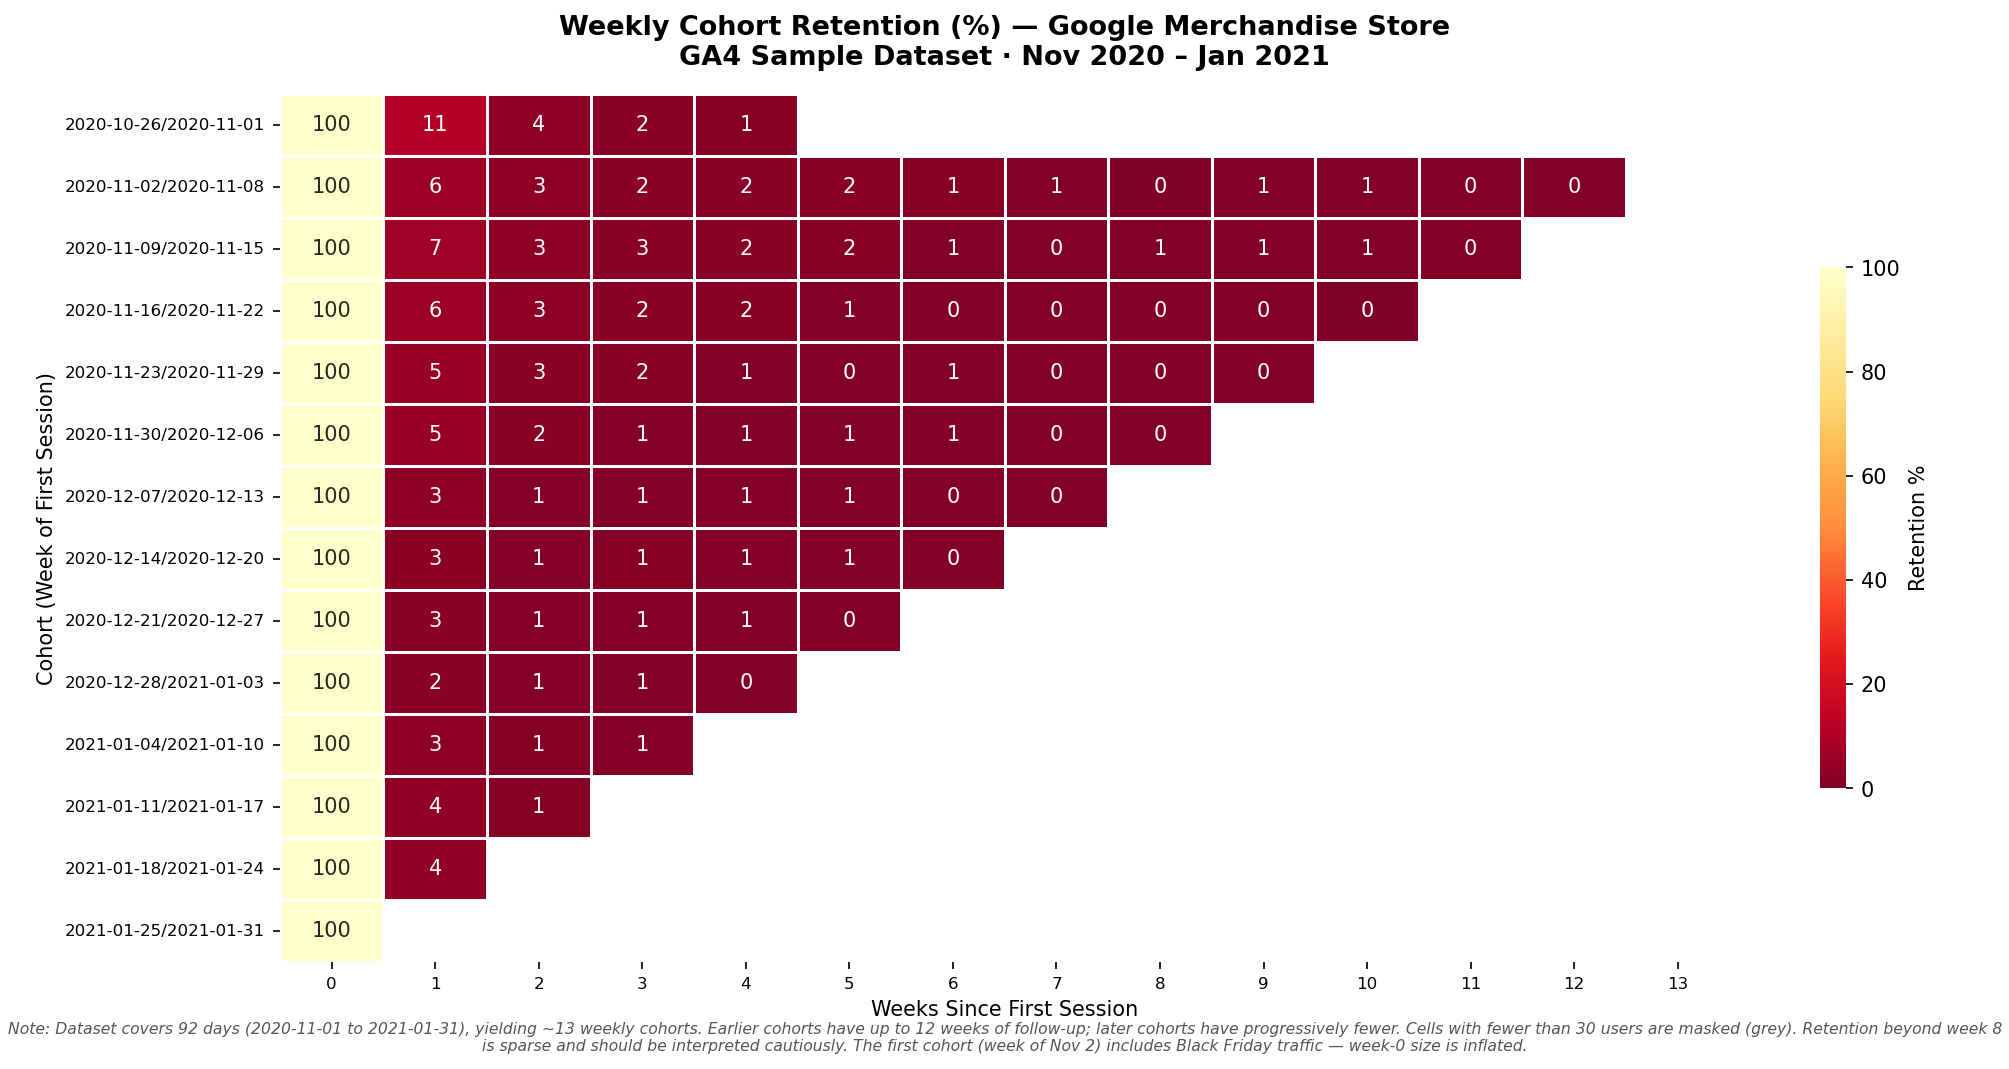

Saved → reports/fig6_cohort_retention.png


In [48]:
fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    retention,
    mask      = mask,
    annot     = True,
    fmt       = '.0f',
    cmap      = 'YlOrRd_r',       # darker = higher retention
    linewidths= 0.5,
    linecolor = 'white',
    cbar_kws  = {'label': 'Retention %', 'shrink': 0.6},
    vmin      = 0,
    vmax      = 100,
    ax        = ax
)

ax.set_title(
    'Weekly Cohort Retention (%) — Google Merchandise Store\n'
    'GA4 Sample Dataset · Nov 2020 – Jan 2021',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel('Weeks Since First Session', fontsize=10)
ax.set_ylabel('Cohort (Week of First Session)', fontsize=10)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8, rotation=0)

# Caption with limitation note
caption = (
    "Note: Dataset covers 92 days (2020-11-01 to 2021-01-31), yielding ~13 weekly cohorts. "
    "Earlier cohorts have up to 12 weeks of follow-up; later cohorts have progressively fewer. "
    f"Cells with fewer than {SPARSE_THRESHOLD} users are masked (grey). "
    "Retention beyond week 8 is sparse and should be interpreted cautiously. "
    "The first cohort (week of Nov 2) includes Black Friday traffic — week-0 size is inflated."
)
fig.text(0.5, -0.1, caption, ha='center', fontsize=7.5,
         color='#555555', wrap=True, style='italic',
         transform=ax.transAxes)

plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, 'fig6_cohort_retention.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## Cell 12 — Cohort business observations

In [49]:
# Week-1 retention across all cohorts (first meaningful return signal)
if 1 in retention.columns:
    w1_ret = retention[1].dropna()
    avg_w1 = w1_ret.mean()
    print(f'Average week-1 retention across all cohorts: {avg_w1:.1f}%')
else:
    print('No week-1 column found — check cohort pivot.')

# Identify earliest cohort (likely Black Friday spike)
first_cohort_label = retention.index[0]
first_cohort_size  = cohort_sizes.iloc[0]

print()
print('='*65)
print('COHORT BUSINESS OBSERVATIONS')
print('='*65)
print(f"""
1. FIRST COHORT (Black Friday week):
   Cohort '{first_cohort_label}' had {int(first_cohort_size):,} users in week 0.
   This is inflated by Black Friday / holiday traffic — week-0 size
   should not be treated as a typical baseline acquisition rate.

2. WEEK-1 RETENTION:
   Average week-1 return rate: {avg_w1:.1f}%. Most e-commerce sites
   target 10–20% for engaged users. Values below this suggest
   opportunity for re-engagement email / push campaigns in days 7–14.

3. DATA LIMITATION:
   With only 92 days of data, cohorts formed in late December and
   January have very little follow-up time. Retention signals for
   these cohorts should not drive strategic conclusions without
   a longer observation window.
""")

Average week-1 retention across all cohorts: 4.8%

COHORT BUSINESS OBSERVATIONS

1. FIRST COHORT (Black Friday week):
   Cohort '2020-10-26/2020-11-01' had 2,361 users in week 0.
   This is inflated by Black Friday / holiday traffic — week-0 size
   should not be treated as a typical baseline acquisition rate.

2. WEEK-1 RETENTION:
   Average week-1 return rate: 4.8%. Most e-commerce sites
   target 10–20% for engaged users. Values below this suggest
   opportunity for re-engagement email / push campaigns in days 7–14.

3. DATA LIMITATION:
   With only 92 days of data, cohorts formed in late December and
   January have very little follow-up time. Retention signals for
   these cohorts should not drive strategic conclusions without
   a longer observation window.



## Cell 13 — NB-05 completion summary

In [50]:
print('='*65)
print('NB-05 COMPLETE — OUTPUTS SUMMARY')
print('='*65)

outputs = [
    ('reports/fig5_purchase_funnel.png',  'Horizontal funnel bar chart'),
    ('reports/fig6_cohort_retention.png', 'Seaborn weekly cohort heatmap'),
    ('reports/funnel_summary.csv',        'Step counts, drop-off %, retention from top'),
    ('reports/cohort_retention.csv',      'Cohort × week retention pivot table'),
]
for path, desc in outputs:
    print(f'  ✓  {path:<42} {desc}')

print()
print('Next notebook → NB-06_explainability.ipynb')
print('  Inputs: models/winner_model.joblib')
print('          models/optimal_threshold.joblib')
print('          data/processed/X_test.parquet')
print('  Remember: apply column name sanitisation before loading into SHAP')
print('  re.sub(r"[^A-Za-z0-9_]", "_", c) on all column names')

NB-05 COMPLETE — OUTPUTS SUMMARY
  ✓  reports/fig5_purchase_funnel.png           Horizontal funnel bar chart
  ✓  reports/fig6_cohort_retention.png          Seaborn weekly cohort heatmap
  ✓  reports/funnel_summary.csv                 Step counts, drop-off %, retention from top
  ✓  reports/cohort_retention.csv               Cohort × week retention pivot table

Next notebook → NB-06_explainability.ipynb
  Inputs: models/winner_model.joblib
          models/optimal_threshold.joblib
          data/processed/X_test.parquet
  Remember: apply column name sanitisation before loading into SHAP
  re.sub(r"[^A-Za-z0-9_]", "_", c) on all column names
